In [22]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency

from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
import umap

DATA_PATH  = library_path.parent / 'data'
PLOTS_PATH = library_path.parent / 'plots'
PLOTS_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

## K-means Clustering and UMAP Visualisation

### Rationale

This notebook addresses **Aim 1**: characterising the subgroup structure of health and
sociodemographic heterogeneity across datasets, and identifying whether certain subgroups
are systematically under- or over-represented in DAPHNIE relative to HSE.

**K-means** partitions the covariate space into $k$ clusters based on Euclidean distance
in standardised feature space. The optimal $k$ is selected by silhouette score and the
elbow method on within-cluster sum of squares.

**UMAP** (Uniform Manifold Approximation and Projection) reduces the high-dimensional
covariate space to 2D for visual inspection. Unlike PCA, UMAP preserves local
neighbourhood structure, making cluster boundaries visible. Colour-coding by dataset
reveals whether DAPHNIE and HSE occupy different regions of the space.

### Feature set

The 17-variable predictor set from notebook 04 is used throughout (same variables as
the density ratio estimation). This ensures clusters are directly interpretable in terms
of the covariate shift already quantified.

### Design

- **Restricted sample:** DAPHNIE 2024 and HSE 2017–2018 only. The full 17-variable
  predictor set (including `resp`, `skin`, `paVig`, `paMod`) is complete only for this
  restricted pair; pooling additional datasets would require dropping these variables.
- Impute missing values (median strategy, primarily `meds_num`) and standardise
- Fit k-means for $k = 2, \ldots, 10$; select optimal $k$ via silhouette score (elbow as secondary check)
- Fit UMAP on the standardised features; colour by dataset, by cluster, and by EQ-5D index
- Profile each cluster: unweighted means per feature and per EQ-5D outcome
- Compute cluster composition by dataset (% of each dataset in each cluster)
- Link clusters to density ratio weights: re-estimate plain LR $w(x)$ and compute mean
  weight per cluster for DAPHNIE 2024 observations — clusters with $w > 1$ are
  underrepresented in DAPHNIE and upscaled by the norm derivation reweighting

In [24]:
df = pd.read_csv(DATA_PATH / 'wrangled_data.csv', low_memory=False)
print(f'Full dataset: {len(df):,} rows x {df.shape[1]} columns')
print(df['dataset'].value_counts().to_string())

Full dataset: 38,995 rows x 63 columns
dataset
HSE 2019        8201
HSE 2018        8177
HSE 2017        7996
HSE 2022        7727
DAPHNIE 2024    5237
DAPHNIE 2023    1657


In [25]:
# 17-variable predictor set (notebook 04)
FEATURES = [
    'Sex', 'age7cat',
    'eth2cat',
    'emp_cat_Employed', 'emp_cat_Other (Sick/Home/etc)', 'emp_cat_Retired',
    'emp_cat_Student', 'emp_cat_Unemployed',
    'edu_cat_2',
    'paVig', 'paMod',
    'smoke_ecig', 'diabetes',
    'meds_num', 'ill_dis',
    'resp', 'skin',
]
FEATURES = [f for f in FEATURES if f in df.columns]
assert len(FEATURES) == 17, f'Expected 17 features, got {len(FEATURES)}'
print(f'Feature set ({len(FEATURES)}): {FEATURES}')

Feature set (17): ['Sex', 'age7cat', 'eth2cat', 'emp_cat_Employed', 'emp_cat_Other (Sick/Home/etc)', 'emp_cat_Retired', 'emp_cat_Student', 'emp_cat_Unemployed', 'edu_cat_2', 'paVig', 'paMod', 'smoke_ecig', 'diabetes', 'meds_num', 'ill_dis', 'resp', 'skin']


## 1. Data Preparation

In [26]:
KEEP_DATASETS = ['DAPHNIE 2024', 'HSE 2017', 'HSE 2018']
df_r = df[df['dataset'].isin(KEEP_DATASETS)].copy().reset_index(drop=True)

print('Restricted dataset:')
print(df_r['dataset'].value_counts().to_string())
print(f'\nTotal: {len(df_r):,} rows')

X_raw = df_r[FEATURES]
miss  = X_raw.isna().sum()
miss  = miss[miss > 0]
if len(miss):
    print('\nVariables with missing values:')
    print(miss.to_string())
else:
    print('\nNo missing values in feature set.')

imputer  = SimpleImputer(strategy='median')
scaler   = StandardScaler()
X_imp    = imputer.fit_transform(X_raw)
X_scaled = scaler.fit_transform(X_imp)
print(f'\nPreprocessed matrix: {X_scaled.shape} (rows x features)')

Restricted dataset:
dataset
HSE 2018        8177
HSE 2017        7996
DAPHNIE 2024    5237

Total: 21,410 rows

Variables with missing values:
Sex            45
age7cat        52
eth2cat        88
edu_cat_2     108
paVig        2550
paMod        2411
meds_num     6744
ill_dis       420

Preprocessed matrix: (21410, 17) (rows x features)


## 2. K-means: Cluster Selection ($k = 2$–$10$)

Inertia (within-cluster sum of squares) and silhouette score are computed for each $k$.
The silhouette score measures how well each observation fits its assigned cluster relative
to the nearest alternative cluster (range $-1$ to $1$; higher is better).
The elbow in inertia serves as a secondary check.

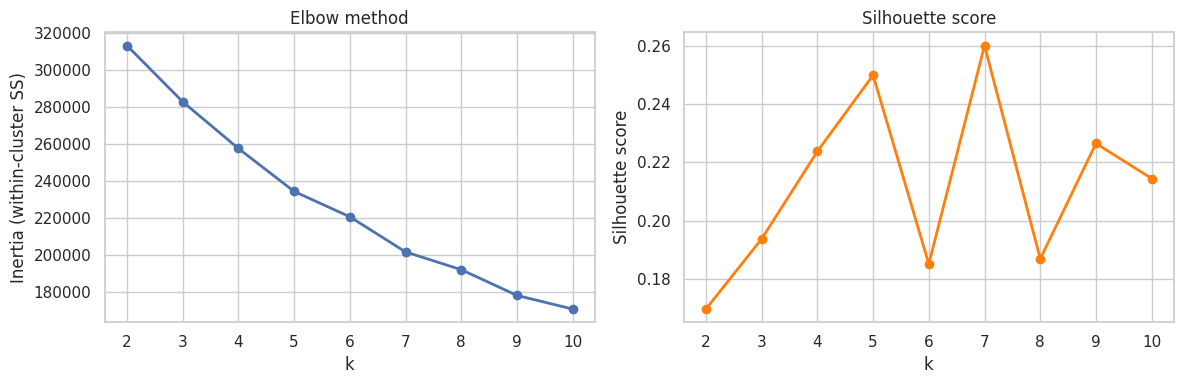

Silhouette scores: {2: 0.1696, 3: 0.1937, 4: 0.2238, 5: 0.25, 6: 0.1851, 7: 0.2602, 8: 0.1869, 9: 0.2265, 10: 0.2145}
Selected k = 7  (peak silhouette = 0.2602)


In [27]:
K_RANGE = range(2, 11)
inertias, silhouettes = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, max_iter=300, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(
        silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias, marker='o', linewidth=2)
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia (within-cluster SS)')
axes[0].set_title('Elbow method')
axes[1].plot(list(K_RANGE), silhouettes, marker='o', linewidth=2, color='tab:orange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score')
plt.tight_layout()
plt.savefig(PLOTS_PATH / 'kmeans_selection.png', dpi=150, bbox_inches='tight')
plt.show()

K_OPT = list(K_RANGE)[int(np.argmax(silhouettes))]
print(f'Silhouette scores: {dict(zip(K_RANGE, [round(s, 4) for s in silhouettes]))}')
print(f'Selected k = {K_OPT}  (peak silhouette = {max(silhouettes):.4f})')

## 3. Final K-means Fit

In [28]:
km_final = KMeans(n_clusters=K_OPT, n_init=20, max_iter=300, random_state=42)
df_r['cluster'] = km_final.fit_predict(X_scaled)

sizes = df_r['cluster'].value_counts().sort_index()
print(f'Cluster sizes (k = {K_OPT}):')
print(sizes.to_string())
print(f'\nSmallest cluster: {sizes.min():,}  ({sizes.min() / len(df_r) * 100:.1f}% of total)')

Cluster sizes (k = 7):
cluster
0     4843
1    10578
2      427
3     1024
4      790
5     1624
6     2124

Smallest cluster: 427  (2.0% of total)


## 4. UMAP Visualisation

UMAP is fitted on the same standardised 17-variable matrix as k-means. Three panels:

1. **By dataset** — do DAPHNIE 2024 and HSE 2017–18 occupy distinct regions of the covariate space?
2. **By cluster** — do k-means boundaries align with the visual structure?
3. **By EQ-5D index** — where do healthy vs unhealthy individuals sit in the embedding?

/home/luis/.cache/pypoetry/virtualenvs/euroqol-lmvfXd04-py3.12/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(


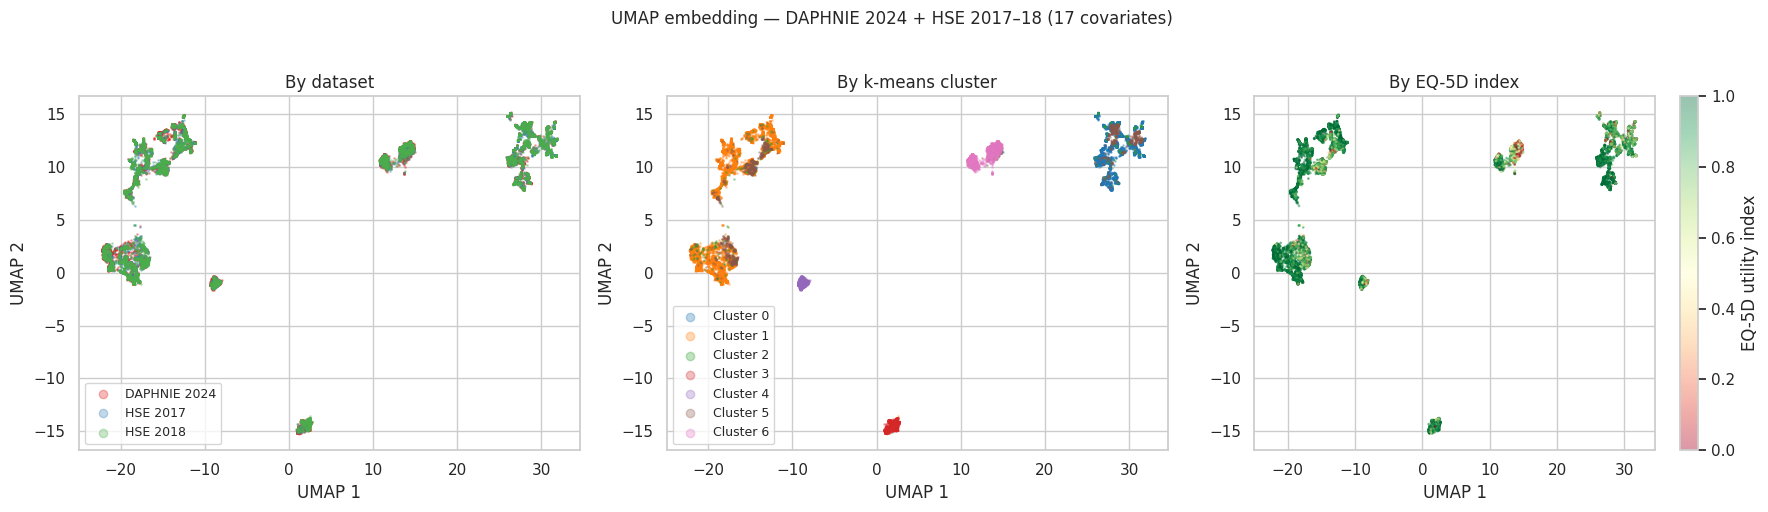

In [29]:
DATASET_COLOURS = {
    'DAPHNIE 2024': '#e41a1c',
    'HSE 2017':     '#377eb8',
    'HSE 2018':     '#4daf4a',
}

reducer = umap.UMAP(n_neighbors=50, min_dist=0.1, n_components=2,
                    random_state=42, n_jobs=1, metric='hamming')
embedding = reducer.fit_transform(X_scaled)
df_r[['umap_1', 'umap_2']] = embedding

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ds, grp in df_r.groupby('dataset'):
    axes[0].scatter(grp['umap_1'], grp['umap_2'],
                    s=1, alpha=0.3, color=DATASET_COLOURS[ds],
                    label=ds, rasterized=True)
axes[0].set_title('By dataset')
axes[0].legend(markerscale=6, framealpha=0.8, fontsize=9)

cluster_palette = sns.color_palette('tab10', n_colors=K_OPT)
for c in sorted(df_r['cluster'].unique()):
    grp = df_r[df_r['cluster'] == c]
    axes[1].scatter(grp['umap_1'], grp['umap_2'],
                    s=1, alpha=0.3, color=cluster_palette[c],
                    label=f'Cluster {c}', rasterized=True)
axes[1].set_title('By k-means cluster')
axes[1].legend(markerscale=6, framealpha=0.8, fontsize=9)

valid = df_r['EQ_index'].notna()
sc = axes[2].scatter(df_r.loc[valid, 'umap_1'], df_r.loc[valid, 'umap_2'],
                     c=df_r.loc[valid, 'EQ_index'], cmap='RdYlGn',
                     s=1, alpha=0.4, vmin=0, vmax=1, rasterized=True)
plt.colorbar(sc, ax=axes[2], label='EQ-5D utility index')
axes[2].set_title('By EQ-5D index')

for ax in axes:
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

plt.suptitle('UMAP embedding — DAPHNIE 2024 + HSE 2017–18 (17 covariates)',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_PATH / 'umap_embedding.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Cluster Profiles

### Sociodemographic profiles

Unweighted mean of each feature per cluster. Colours show the z-score across clusters;
cell annotations show raw means.

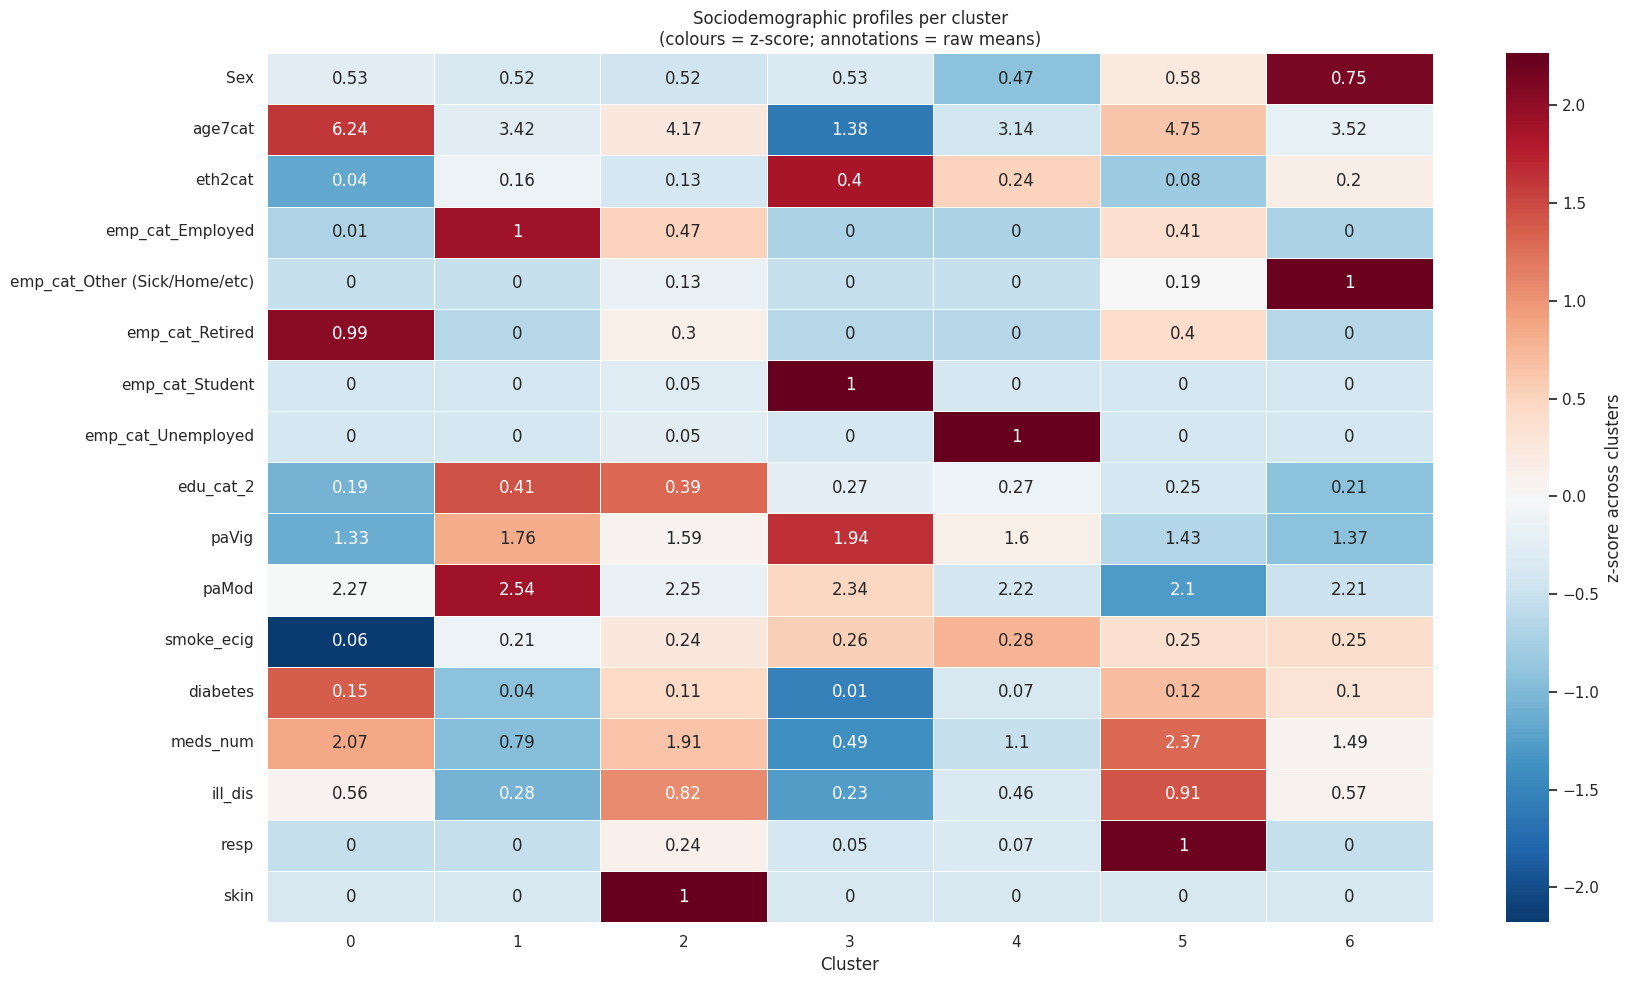

In [30]:
profile_raw = df_r.groupby('cluster')[FEATURES].mean()
profile_z   = (profile_raw - profile_raw.mean()) / profile_raw.std().replace(0, 1)

fig, ax = plt.subplots(figsize=(max(8, K_OPT * 2.5), 10))
sns.heatmap(profile_z.T,
            annot=profile_raw.T.round(2), fmt='g',
            cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.5,
            cbar_kws={'label': 'z-score across clusters'})
ax.set_xlabel('Cluster')
ax.set_ylabel('')
ax.set_title('Sociodemographic profiles per cluster\n(colours = z-score; annotations = raw means)')
plt.tight_layout()
plt.savefig(PLOTS_PATH / 'cluster_feature_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

### Health outcome profiles

Unweighted mean of each EQ-5D outcome and `srh` per cluster.

,MO5L,SC5L,UA5L,PD5L,AD5L,EQ_index,LSS_rs,srh
cluster,,,,,,,,
0,1.652,1.195,1.514,1.962,1.386,0.857,86.562,3.620
1,1.173,1.051,1.172,1.519,1.475,0.925,93.080,4.041
2,1.655,1.301,1.667,2.051,1.832,0.793,82.340,3.253
3,1.143,1.064,1.203,1.377,1.677,0.915,92.707,4.146
4,1.456,1.222,1.533,1.798,2.178,0.806,84.204,3.291
5,1.915,1.415,1.877,2.226,1.860,0.746,78.698,3.046
6,1.814,1.519,1.919,2.193,2.217,0.697,76.683,3.233


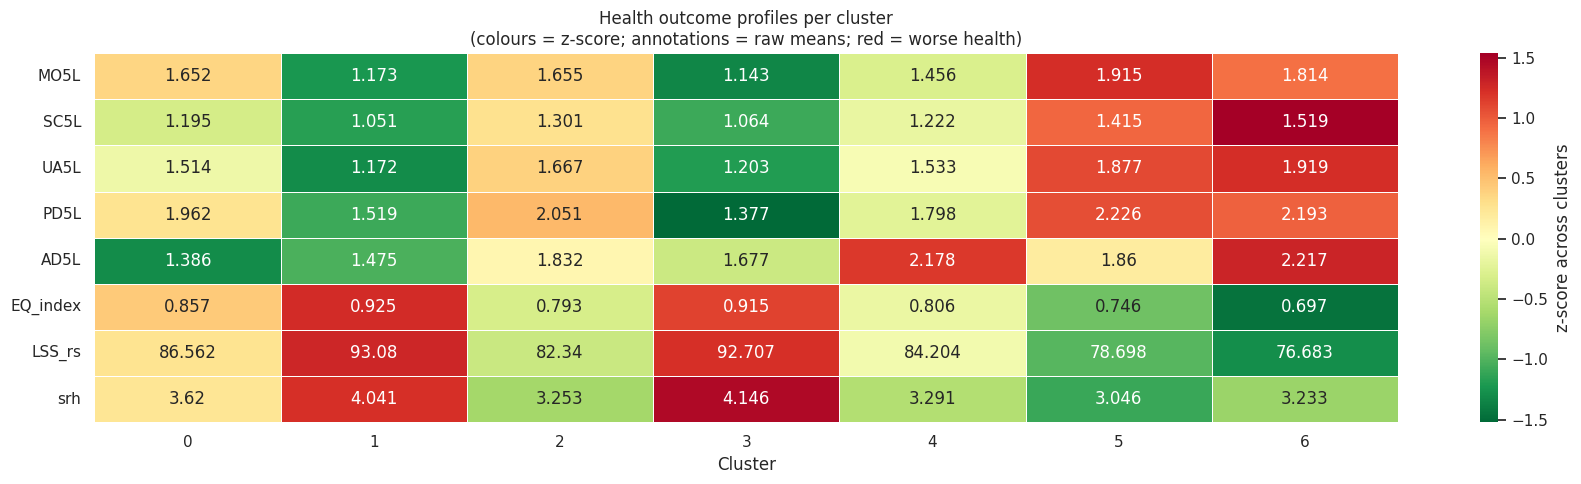

In [31]:
OUTCOMES = ['MO5L', 'SC5L', 'UA5L', 'PD5L', 'AD5L', 'EQ_index', 'LSS_rs', 'srh']
OUTCOMES  = [o for o in OUTCOMES if o in df_r.columns]

outcome_profile = df_r.groupby('cluster')[OUTCOMES].mean()
display(outcome_profile.round(3))

outcome_z = (outcome_profile - outcome_profile.mean()) / outcome_profile.std().replace(0, 1)

fig, ax = plt.subplots(figsize=(max(8, K_OPT * 2.5), 5))
sns.heatmap(outcome_z.T,
            annot=outcome_profile.T.round(3), fmt='g',
            cmap='RdYlGn_r', center=0, ax=ax,
            linewidths=0.5,
            cbar_kws={'label': 'z-score across clusters'})
ax.set_xlabel('Cluster')
ax.set_ylabel('')
ax.set_title('Health outcome profiles per cluster\n(colours = z-score; annotations = raw means; red = worse health)')
plt.tight_layout()
plt.savefig(PLOTS_PATH / 'cluster_outcome_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Cluster Composition by Dataset

Two views of the cluster × dataset cross-tabulation:

- **Left panel:** what share of each cluster comes from DAPHNIE 2024 vs HSE?
  Clusters dominated by DAPHNIE mark regions where the online panel is overrepresented.
- **Right panel:** how is each dataset distributed across clusters?
  Reveals systematic concentration of one dataset in particular health/SES subgroups.

A chi-squared test assesses whether cluster assignment is independent of dataset.

Cluster composition — % from each dataset (rows sum to 100%):


dataset,DAPHNIE 2024,HSE 2017,HSE 2018
cluster,,,
0,19.500,40.800,39.700
1,23.800,37.700,38.500
2,37.900,30.000,32.100
3,28.900,31.300,39.700
4,50.500,24.700,24.800
5,24.600,36.800,38.700
6,24.500,37.100,38.400



Dataset allocation across clusters — % of each dataset per cluster (cols sum to 100%):


dataset,DAPHNIE 2024,HSE 2017,HSE 2018
cluster,,,
0,18.100,24.700,23.500
1,48.000,49.900,49.800
2,3.100,1.600,1.700
3,5.700,4.000,5.000
4,7.600,2.400,2.400
5,7.600,7.500,7.700
6,9.900,9.900,10.000



Chi-squared (cluster independent of dataset): chi2=420.3, df=12, p=1.88e-82


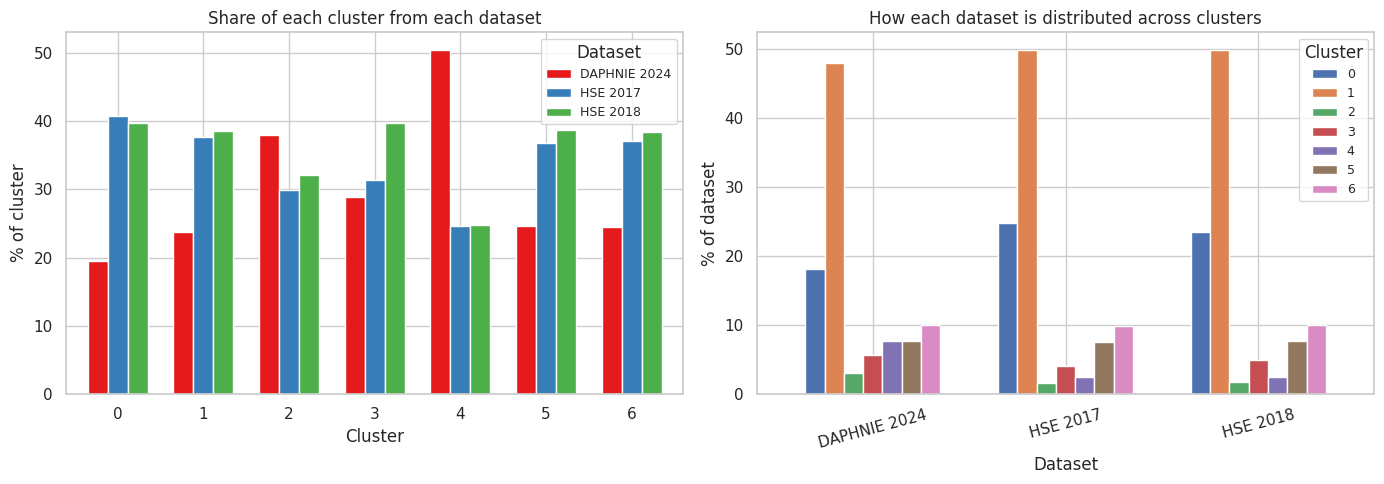

In [32]:
comp_n = (df_r.groupby(['cluster', 'dataset'])
          .size()
          .unstack(fill_value=0))

comp_pct_row = comp_n.div(comp_n.sum(axis=1), axis=0).mul(100)
print('Cluster composition — % from each dataset (rows sum to 100%):')
display(comp_pct_row.round(1))

comp_pct_col = comp_n.div(comp_n.sum(axis=0), axis=1).mul(100)
print('\nDataset allocation across clusters — % of each dataset per cluster (cols sum to 100%):')
display(comp_pct_col.round(1))

chi2_stat, p_chi, dof, _ = chi2_contingency(comp_n.values)
print(f'\nChi-squared (cluster independent of dataset): chi2={chi2_stat:.1f}, df={dof}, p={p_chi:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comp_pct_row.plot(kind='bar', ax=axes[0],
                  color=[DATASET_COLOURS[c] for c in comp_pct_row.columns],
                  edgecolor='white', width=0.7)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('% of cluster')
axes[0].set_title('Share of each cluster from each dataset')
axes[0].legend(title='Dataset', fontsize=9)
axes[0].tick_params(axis='x', rotation=0)

comp_pct_col.T.plot(kind='bar', ax=axes[1], edgecolor='white', width=0.7)
axes[1].set_xlabel('Dataset')
axes[1].set_ylabel('% of dataset')
axes[1].set_title('How each dataset is distributed across clusters')
axes[1].legend(title='Cluster', fontsize=9)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(PLOTS_PATH / 'cluster_composition.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Link to Norm Derivation (Aim 2): Density Ratio Weights per Cluster

The plain LR density ratio from notebook 04 is re-estimated here (self-contained, same
architecture and predictor set) to connect the cluster structure to the reweighting used
in norm derivation.

$$w(x) = \frac{\hat{P}(\text{HSE} \mid x)}{1 - \hat{P}(\text{HSE} \mid x)}$$

- $w > 1$: this observation looks more like HSE than DAPHNIE → **underrepresented** in
  the online panel; the reweighting upscales these observations when deriving norms.
- $w < 1$: the observation is more characteristic of DAPHNIE → **overrepresented**;
  the reweighting downscales.

Mapping the mean cluster weight back to the cluster profiles from Section 5 gives a
mechanistic account of *which subgroups* the norm derivation correction is acting on.

Weight range (clipped + normalised): 0.026 – 4.948
ESS: 3022 / 5237 (57.7%)

Mean density ratio weight per cluster (DAPHNIE 2024 observations):
  w > 1: underrepresented in DAPHNIE  |  w < 1: overrepresented


,mean,median,std
cluster,,,
0,1.295,1.048,0.948
1,1.046,0.778,0.859
2,0.510,0.375,0.450
3,0.930,0.670,0.855
4,0.338,0.282,0.260
5,0.910,0.741,0.726
6,1.013,0.829,0.809


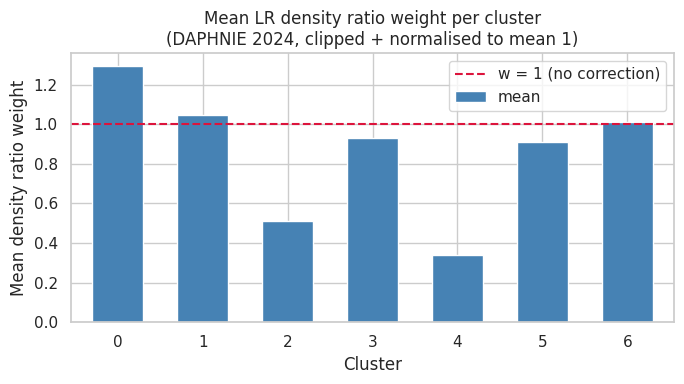

In [33]:
df_r['is_hse'] = df_r['dataset'].isin(['HSE 2017', 'HSE 2018']).astype(int)

lr_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('lr',      LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
])
lr_pipe.fit(df_r[FEATURES], df_r['is_hse'])

p_hat = lr_pipe.predict_proba(df_r[FEATURES])[:, 1]
p_hat = np.clip(p_hat, 1e-6, 1 - 1e-6)
w_raw = p_hat / (1 - p_hat)

daphnie_mask = df_r['dataset'] == 'DAPHNIE 2024'
w_d      = w_raw[daphnie_mask.values]
clip_val = np.percentile(w_d, 99)
w_norm   = np.minimum(w_d, clip_val)
w_norm   = w_norm / w_norm.mean()

df_r['w_lr'] = np.nan
df_r.loc[daphnie_mask, 'w_lr'] = w_norm

ess = w_norm.sum() ** 2 / (w_norm ** 2).sum()
n_d = int(daphnie_mask.sum())
print(f'Weight range (clipped + normalised): {w_norm.min():.3f} – {w_norm.max():.3f}')
print(f'ESS: {ess:.0f} / {n_d} ({ess / n_d * 100:.1f}%)')

w_summary = df_r[daphnie_mask].groupby('cluster')['w_lr'].agg(['mean', 'median', 'std'])
print('\nMean density ratio weight per cluster (DAPHNIE 2024 observations):')
print('  w > 1: underrepresented in DAPHNIE  |  w < 1: overrepresented')
display(w_summary.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
w_summary['mean'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', width=0.6)
ax.axhline(1.0, color='crimson', linestyle='--', linewidth=1.5, label='w = 1 (no correction)')
ax.set_xlabel('Cluster')
ax.set_ylabel('Mean density ratio weight')
ax.set_title('Mean LR density ratio weight per cluster\n(DAPHNIE 2024, clipped + normalised to mean 1)')
ax.legend()
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(PLOTS_PATH / 'cluster_density_ratio_weights.png', dpi=150, bbox_inches='tight')
plt.show()